# Statistics Across Noise Levels — EuroSAT QRC vs Baseline

Loads per-image metric arrays saved by `Denoise_EuroSAT_QRC.ipynb`
(cell "Save Per-Image Metrics", one `.npz` per σ) and compares the hybrid
(PCA+QRC+MLP) against the classical baseline (PCA+MLP) across noise levels.

Per (σ, metric): mean paired Δ (hybrid − baseline), 95% bootstrap CI,
paired t-test, Wilcoxon signed-rank, sign test.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_1samp, wilcoxon, binomtest, norm

SEED   = 42
D_QRC  = 18
SIGMAS = [0.1, 0.3, 0.5, 0.7]
MODEL_DIR = Path("models/eurosat_qrc")

# metric name -> (delta better direction, scale factor for display)
METRICS = ["mse", "ssim", "teng"]
BETTER  = {"mse": "< 0", "ssim": "> 0", "teng": "> 0"}

runs = {}
for s in SIGMAS:
    p = MODEL_DIR / f"sigma{s}_per_image_metrics_d{D_QRC}.npz"
    if not p.exists():
        print(f"MISSING: {p} — run Denoise_EuroSAT_QRC.ipynb with SIGMA={s}")
        continue
    runs[s] = np.load(p)
    print(f"loaded σ={s}: n = {len(runs[s]['mse_hybrid'])}")

loaded σ=0.1: n = 2700
loaded σ=0.3: n = 2700
loaded σ=0.5: n = 2700
loaded σ=0.7: n = 2700


### Paired statistics per (σ, metric)

In [ ]:
def bootstrap_stat(measurements, stat=np.mean, n_bootstrap=10_000, seed=SEED):
    """Bootstrap distribution of an arbitrary statistic (np.mean, np.median, ...)."""
    rng = np.random.default_rng(seed)
    n = len(measurements)
    resamples = rng.choice(measurements, size=(n_bootstrap, n), replace=True)
    return stat(resamples, axis=1)


def fmt_p(p, z=None):
    """Format a p-value; on float64 underflow, recover order of magnitude from z."""
    if p > 0:
        return f"{p:.2e}"
    if z is not None:
        log10_p = (norm.logsf(abs(z)) + np.log(2)) / np.log(10)
        return f"<1e{log10_p:.0f}"
    return "<5e-324"


def paired_stats(delta):
    lo, hi = np.percentile(bootstrap_stat(delta, np.mean), [2.5, 97.5])
    med_lo, med_hi = np.percentile(bootstrap_stat(delta, np.median), [2.5, 97.5])
    t = ttest_1samp(delta, 0.0)
    w = wilcoxon(delta, method="approx")
    n_pos, n_tot = int((delta > 0).sum()), int((delta != 0).sum())
    s = binomtest(n_pos, n_tot, 0.5)
    return {
        "mean": delta.mean(), "median": np.median(delta), "std": delta.std(),
        "ci": (lo, hi),
        "ci_med": (med_lo, med_hi),
        "p_t": fmt_p(t.pvalue, t.statistic),
        "p_w": fmt_p(w.pvalue, w.zstatistic),
        "p_s": fmt_p(s.pvalue),
        "win_pct": 100 * n_pos / n_tot,   # % of images where hybrid delta > 0
    }


stats = {}   # stats[metric][sigma] -> dict
for m in METRICS:
    stats[m] = {}
    for s, r in runs.items():
        stats[m][s] = paired_stats(r[f"{m}_hybrid"] - r[f"{m}_baseline"])

for m in METRICS:
    print(f"\nΔ{m.upper()} (hybrid − baseline)   [{BETTER[m]} → hybrid better]")
    print(f"{'σ':>5}{'mean':>12}{'median':>12}{'95% CI':>28}{'p (t)':>10}{'p (W)':>10}{'p (sign)':>10}")
    print("-" * 87)
    for s in SIGMAS:
        if s not in stats[m]:
            continue
        st = stats[m][s]
        ci = f"[{st['ci'][0]:+.6f}, {st['ci'][1]:+.6f}]"
        print(f"{s:>5}{st['mean']:>+12.6f}{st['median']:>+12.6f}{ci:>28}"
              f"{st['p_t']:>10}{st['p_w']:>10}{st['p_s']:>10}")


ΔMSE (hybrid − baseline)   [< 0 → hybrid better]
    σ        mean      median                      95% CI     p (t)     p (W)  p (sign)
---------------------------------------------------------------------------------------
  0.1   +0.000255   +0.000102      [+0.000232, +0.000279]   <1e-101   <1e-344   <5e-324
  0.3   +0.000260   +0.000104      [+0.000239, +0.000285]   <1e-109   <1e-342   <5e-324
  0.5   +0.000258   +0.000111      [+0.000236, +0.000280]   <1e-120   <1e-266 1.42e-253
  0.7   +0.000288   +0.000129      [+0.000266, +0.000310]   <1e-150   <1e-248 2.87e-209

ΔSSIM (hybrid − baseline)   [> 0 → hybrid better]
    σ        mean      median                      95% CI     p (t)     p (W)  p (sign)
---------------------------------------------------------------------------------------
  0.1   -0.003140   -0.001933      [-0.003428, -0.002850]   <1e-100   <1e-142 3.89e-126
  0.3   -0.003823   -0.001916      [-0.004160, -0.003494]   <1e-115   <1e-148 1.66e-107
  0.5   -0.002147  

### Δ metric vs noise level

Mean paired difference with 95% bootstrap CI per σ. CI bar not crossing the zero
line = difference statistically significant at that noise level. CIs are narrow
(SE ~ std/√2700) — often smaller than the marker.

/tmp/ipykernel_742596/169007681.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


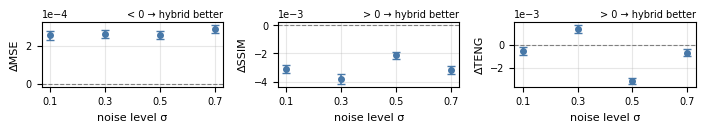

saved figures/delta_vs_sigma.pdf (+ .png preview)


In [72]:
# Paper-ready figure: mean Δ ± 95% CI vs σ (IEEE two-column span: \figure* ~7.16 in)
LABELS = {"mse": "ΔMSE", "ssim": "ΔSSIM", "teng": "ΔTENG"}

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(7.16, 1.45), constrained_layout=True)
for ax, m in zip(axes, METRICS):
    sig  = [s for s in SIGMAS if s in stats[m]]
    mean = np.array([stats[m][s]["mean"] for s in sig])
    lo   = np.array([stats[m][s]["ci"][0] for s in sig])
    hi   = np.array([stats[m][s]["ci"][1] for s in sig])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.errorbar(sig, mean, yerr=[mean - lo, hi - mean],
                fmt="o", color="#4878a8", markersize=4,
                capsize=3, elinewidth=1.2)
    ax.set_xlabel("noise level σ", fontsize=8)
    ax.set_ylabel(LABELS[m], fontsize=8)
    ax.set_title(f"{BETTER[m]} → hybrid better", loc="right", fontsize=7, color="black", y=1.05, pad=1)
    ax.set_xticks(sig)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
    ax.yaxis.get_offset_text().set_fontsize(7)

plt.tight_layout()
fig.savefig(FIG_DIR / "delta_vs_sigma.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "delta_vs_sigma.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {FIG_DIR}/delta_vs_sigma.pdf (+ .png preview)")

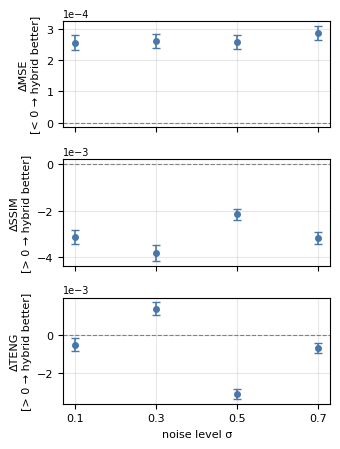

saved figures/delta_vs_sigma_1col.pdf (+ .png preview)


In [54]:
# Single-column variant: mean Δ ± 95% CI vs σ, panels stacked vertically (IEEE \figure ~3.5 in)
fig, axes = plt.subplots(3, 1, figsize=(3.5, 4.6), sharex=True)
for ax, m in zip(axes, METRICS):
    sig  = [s for s in SIGMAS if s in stats[m]]
    mean = np.array([stats[m][s]["mean"] for s in sig])
    lo   = np.array([stats[m][s]["ci"][0] for s in sig])
    hi   = np.array([stats[m][s]["ci"][1] for s in sig])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.errorbar(sig, mean, yerr=[mean - lo, hi - mean],
                fmt="o", color="#4878a8", markersize=4,
                capsize=3, elinewidth=1.2)
    ax.set_ylabel(f"{LABELS[m]}\n[{BETTER[m]} → hybrid better]", fontsize=8)
    ax.set_xticks(sig)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
    ax.yaxis.get_offset_text().set_fontsize(7)

axes[-1].set_xlabel("noise level σ", fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / "delta_vs_sigma_1col.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "delta_vs_sigma_1col.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {FIG_DIR}/delta_vs_sigma_1col.pdf (+ .png preview)")


### Median vs mean across σ

Mean and median diverging (opposite signs at some σ for TENG) = outlier-dominated
mean; see the per-image histograms in the main notebook.

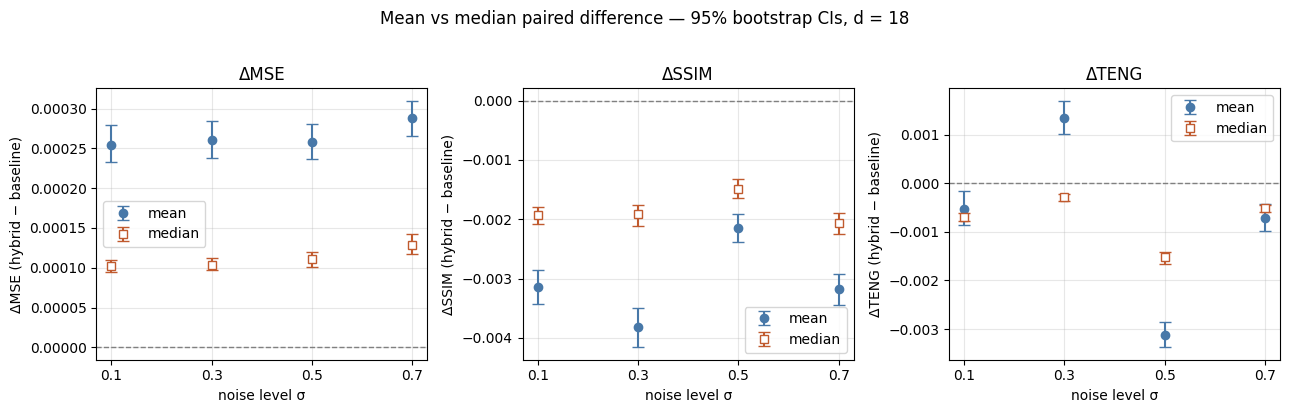

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, METRICS):
    sig    = [s for s in SIGMAS if s in stats[m]]
    mean   = np.array([stats[m][s]["mean"] for s in sig])
    m_lo   = np.array([stats[m][s]["ci"][0] for s in sig])
    m_hi   = np.array([stats[m][s]["ci"][1] for s in sig])
    median = np.array([stats[m][s]["median"] for s in sig])
    d_lo   = np.array([stats[m][s]["ci_med"][0] for s in sig])
    d_hi   = np.array([stats[m][s]["ci_med"][1] for s in sig])

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.errorbar(sig, mean, yerr=[mean - m_lo, m_hi - mean],
                fmt="o", color="#4878a8", markersize=6,
                capsize=4, elinewidth=1.5, label="mean")
    ax.errorbar(sig, median, yerr=[median - d_lo, d_hi - median],
                fmt="s", color="#c05a2e", markersize=6, markerfacecolor="white",
                capsize=4, elinewidth=1.5, label="median")
    ax.set_xlabel("noise level σ")
    ax.set_ylabel(f"{LABELS[m]} (hybrid − baseline)")
    ax.set_title(LABELS[m])
    ax.set_xticks(sig)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(f"Mean vs median paired difference — 95% bootstrap CIs, d = {D_QRC}", y=1.02)
plt.tight_layout()
plt.show()

### Hybrid win rate vs noise

% of test images where the hybrid is better (direction-corrected per metric).

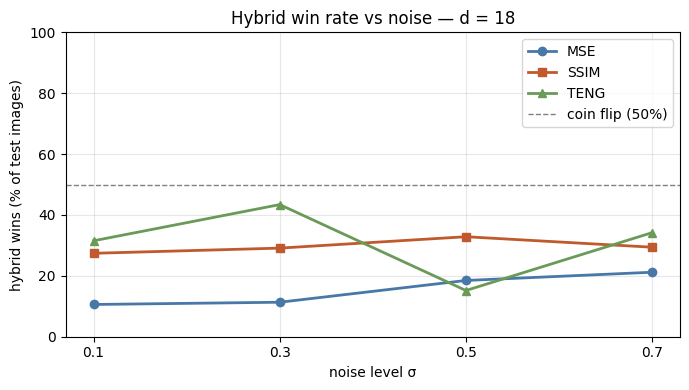

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
markers = {"mse": "o", "ssim": "s", "teng": "^"}
colors  = {"mse": "#4878a8", "ssim": "#c05a2e", "teng": "#6a9a58"}
for m in METRICS:
    sig = [s for s in SIGMAS if s in stats[m]]
    # win_pct stores %(delta > 0); for MSE hybrid wins when delta < 0
    win = [100 - stats[m][s]["win_pct"] if BETTER[m] == "< 0" else stats[m][s]["win_pct"]
           for s in sig]
    ax.plot(sig, win, marker=markers[m], color=colors[m], linewidth=2,
            markersize=6, label=LABELS[m].replace("Δ", ""))

ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="coin flip (50%)")
ax.set_xlabel("noise level σ")
ax.set_ylabel("hybrid wins (% of test images)")
ax.set_title(f"Hybrid win rate vs noise — d = {D_QRC}")
ax.set_xticks(SIGMAS)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Qualitative reconstruction vs noise (paper figure)

One texture-rich test image across all σ. Clean shown once (left, σ-independent);
rows follow the pipeline: noisy input → PCA(18) projection → baseline MLP → hybrid
QRC. The PCA projection row already shows the smoothing seen in both
reconstructions — the dimensionality bottleneck, not the readout, limits quality.
SSIM vs clean annotated per panel.

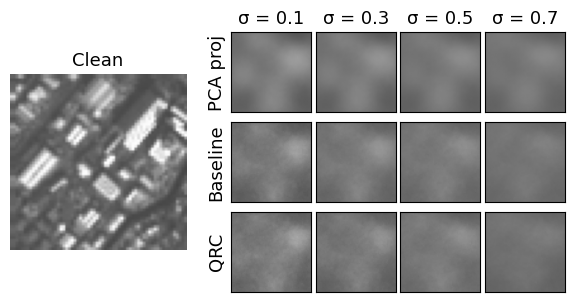

saved figures/qualitative_vs_sigma.pdf (+ .png preview)


In [62]:
from matplotlib.gridspec import GridSpec

ROWS = [
    ("pca",      "PCA proj"),
    ("baseline", "Baseline"),
    ("hybrid",   "QRC"),
]

sigmas = [s for s in SIGMAS if s in runs]
n_col = len(sigmas)

fig = plt.figure(figsize=(7.16, 3.5))
gs = GridSpec(3, n_col + 2, figure=fig,
              width_ratios=[2.2, 0.45] + [1.0] * n_col, wspace=0.05, hspace=0.0)

# clean reference — once, spanning all rows (image centers vertically)
ax_clean = fig.add_subplot(gs[:, 0])
clean_img = runs[sigmas[0]]["showcase_clean"].reshape(64, 64)
ax_clean.imshow(clean_img, cmap="gray", vmin=0, vmax=1)
ax_clean.set_title("Clean", fontsize=13)
ax_clean.set_xticks([]); ax_clean.set_yticks([])
ax_clean.set_frame_on(False)

for r, (key, label) in enumerate(ROWS):
    for c, s in enumerate(sigmas):
        ax = fig.add_subplot(gs[r, c + 2])
        img = np.clip(runs[s][f"showcase_{key}"].reshape(64, 64), 0, 1)
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(f"σ = {s}", fontsize=13)
        if c == 0:
            ax.set_ylabel(label, fontsize=13)

fig.savefig(FIG_DIR / "qualitative_vs_sigma.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "qualitative_vs_sigma.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {FIG_DIR}/qualitative_vs_sigma.pdf (+ .png preview)")
